In [2]:
import numpy as np
import random
from collections import namedtuple, deque
import math
from matplotlib import pyplot as plt
import matplotlib

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

In [4]:
is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
    from IPython import display

# MDP


In [5]:
from sepsisSimDiabetes.Action import Action
from sepsisSimDiabetes.State import State
from sepsisSimDiabetes.MDP import MDP

# Deep Q-Learning

In [6]:
from dqn import DQN, ReplayBuffer, train_dqn, device, LR

In [7]:
BUFFER_CAPACITY = 10_000
NUM_EPISODES = 10_000
T = 14

In [12]:
policy_net = DQN(n_observations=State.NUM_STATE_VARS,
                 hidden_dim=128,
                 n_actions=Action.NUM_ACTIONS_TOTAL).to(device)
target_net = DQN(n_observations=State.NUM_STATE_VARS,
                 hidden_dim=128,
                 n_actions=Action.NUM_ACTIONS_TOTAL).to(device)
target_net.load_state_dict(policy_net.state_dict())

optimizer = optim.AdamW(policy_net.parameters(), lr=LR, amsgrad=True)
memory = ReplayBuffer(BUFFER_CAPACITY)


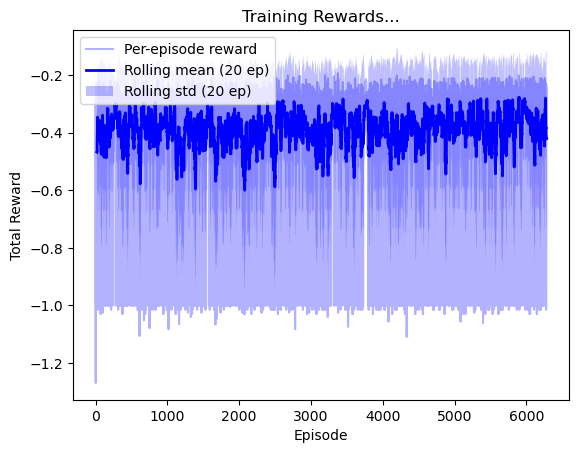

<Figure size 640x480 with 0 Axes>

In [ ]:
final_policy_net, final_target_net = train_dqn(memory, policy_net, target_net, optimizer, NUM_EPISODES, T)
torch.save(final_policy_net.state_dict(), 'results/dqn_weights.pt')
print("Saved DQN policy network")

# PPO

In [8]:
from ppo import train_ppo

iter=499 | steps=849 | avg_ep_len=13.3 | avg_ep_return=-1282.62


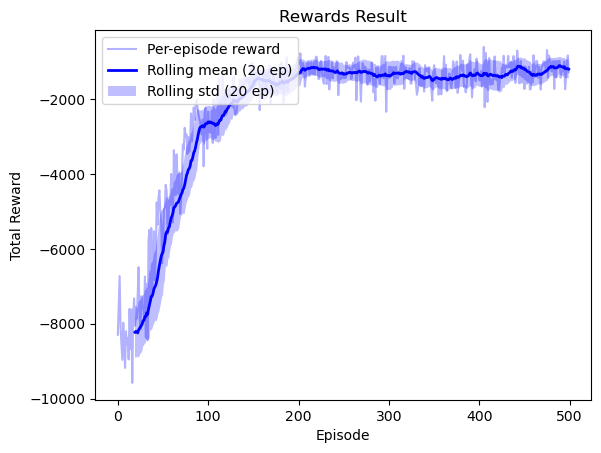

<Figure size 640x480 with 0 Axes>

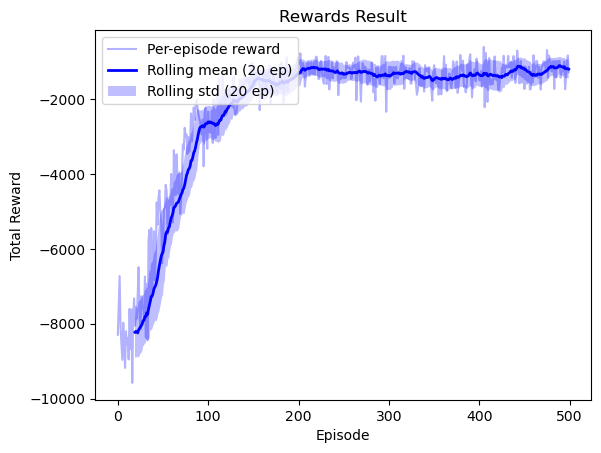

<Figure size 640x480 with 0 Axes>


ppo training done
mean reward: -2212.57 +/- 1909.62
last 20 eps: -1200.63 +/- 244.89
saved to results/


<Figure size 640x480 with 0 Axes>

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

NUM_UPDATES = 500         
T = 14         
BATCH_SIZE = 128
GAMMA = 0.99
LR = 3e-4


LAMBDA = 0.95
CLIP_EPS = 0.2
EPOCHS = 4
VALUE_COEF = 0.5
ENTROPY_COEF = 0.01
REWARD_SCALE = 1e-4


ppo_model, episode_rewards = train_ppo(
    iters=NUM_UPDATES,
    rollout_episodes=64,
    max_steps=T,
    gamma=GAMMA,
    lambda_param=LAMBDA,
    clip_epsilon=CLIP_EPS,
    lr=LR,
    training_epochs=EPOCHS,
    minibatch_size=BATCH_SIZE,
    value_coef=VALUE_COEF,
    entropy_coef=ENTROPY_COEF,
    reward_scaling=REWARD_SCALE,
    device=device,
)
torch.save(ppo_model.state_dict(), 'results/ppo_weights.pt')
print("Saved PPO policy network")

# Rendering Trajectories

In [12]:
from render_trajectories import render_trajectory

random_baseline = True
print(render_trajectory(None, device, model_type = "random"))
#print(render_trajectory(ppo_model, device, model_type = "ppo")) #render ppo
#print(render_trajectory(final_policy_net, device, model_type = "dqn")) #render dqn


   New Episode   
Diabetic: False

Step 1:
  Vitals    — HR: normal, BP: normal, O2: normal, Glucose: very low
  Location  — async/remote
  Capacity  — Outpatient docs: moderate, Outpatient nurses: largely available
  Treatment — Antibiotics: True, Vasopressors: True, Ventilation: True, Non-invasive vent: True
  Reward    — -150.0

Step 2:
  Vitals    — HR: normal, BP: normal, O2: normal, Glucose: very low
  Location  — async/remote
  Capacity  — Outpatient docs: moderate, Outpatient nurses: largely available
  Treatment — Antibiotics: True, Vasopressors: True, Ventilation: True, Non-invasive vent: True
  Reward    — -150.0

Step 3:
  Vitals    — HR: normal, BP: high, O2: normal, Glucose: very low
  Location  — ambulatory
  Capacity  — Outpatient docs: moderate, Outpatient nurses: largely available
  Treatment — Antibiotics: True, Vasopressors: True, Ventilation: True, Non-invasive vent: True
  Reward    — -312.5

Step 4:
  Vitals    — HR: normal, BP: high, O2: normal, Glucose: very lo